# prototype of an expert system to evaluate building damage and provide reliable recommendations despite uncertaintines


### Student Name:Rand M. M. Salem
###  Student ID: 220210128

#### **1. Fuzzy Logic Setup**
- **Input Variables**: `damage_severity` and `population_density` are defined as fuzzy variables with ranges from 0 to 10.
- **Output Variable**: `reconstruction_priority` is the output fuzzy variable.
- **Membership Functions**: Triangular membership functions (`trimf`) are used to define low, medium, and high categories for each variable.

#### **2. Rules**
- Three rules are defined to link input variables to the output:
  1. If damage severity is high and population density is high, then reconstruction priority is high.
  2. If damage severity is medium and population density is medium, then reconstruction priority is medium.
  3. If damage severity is low and population density is low, then reconstruction priority is low.

#### **3. Control System**
- A control system is created using the defined rules, and a simulation object (`reconstruction_sim`) is initialized.

#### **4. Testing Function**
- The `test_reconstruction_system` function takes damage severity and population density as inputs, computes the reconstruction priority, and prints the result.

#### **5. Test Cases**
- Three test cases are provided to demonstrate the system's functionality:
  1. High damage severity and high population density (expected: high priority).
  2. Medium damage severity and medium population density (expected: medium priority).
  3. Low damage severity and low population density (expected: low priority).

In [7]:
pip install scikit-fuzzy

Note: you may need to restart the kernel to use updated packages.


In [8]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import seaborn as sns

# Define input variables (e.g., damage severity, population density)
damage_severity = ctrl.Antecedent(np.arange(0, 11, 1), 'damage_severity')
population_density = ctrl.Antecedent(np.arange(0, 11, 1), 'population_density')

# Define output variable (e.g., reconstruction priority)
reconstruction_priority = ctrl.Consequent(np.arange(0, 11, 1), 'reconstruction_priority')

# Define membership functions for damage severity
damage_severity['low'] = fuzz.trimf(damage_severity.universe, [0, 0, 5])
damage_severity['medium'] = fuzz.trimf(damage_severity.universe, [0, 5, 10])
damage_severity['high'] = fuzz.trimf(damage_severity.universe, [5, 10, 10])

# Define membership functions for population density
population_density['low'] = fuzz.trimf(population_density.universe, [0, 0, 5])
population_density['medium'] = fuzz.trimf(population_density.universe, [0, 5, 10])
population_density['high'] = fuzz.trimf(population_density.universe, [5, 10, 10])

# Define membership functions for reconstruction priority
reconstruction_priority['low'] = fuzz.trimf(reconstruction_priority.universe, [0, 0, 5])
reconstruction_priority['medium'] = fuzz.trimf(reconstruction_priority.universe, [0, 5, 10])
reconstruction_priority['high'] = fuzz.trimf(reconstruction_priority.universe, [5, 10, 10])

# Define rules
rule1 = ctrl.Rule(damage_severity['high'] & population_density['high'], reconstruction_priority['high'])
rule2 = ctrl.Rule(damage_severity['medium'] & population_density['medium'], reconstruction_priority['medium'])
rule3 = ctrl.Rule(damage_severity['low'] & population_density['low'], reconstruction_priority['low'])

# Create control system
reconstruction_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
reconstruction_sim = ctrl.ControlSystemSimulation(reconstruction_ctrl)

# Test the system with input values
reconstruction_sim.input['damage_severity'] = 8
reconstruction_sim.input['population_density'] = 7
reconstruction_sim.compute()

# Output the result
print("Reconstruction Priority:", reconstruction_sim.output['reconstruction_priority'])

Reconstruction Priority: 5.481481481481482


### 3D Visualizationof the Fuzzy System

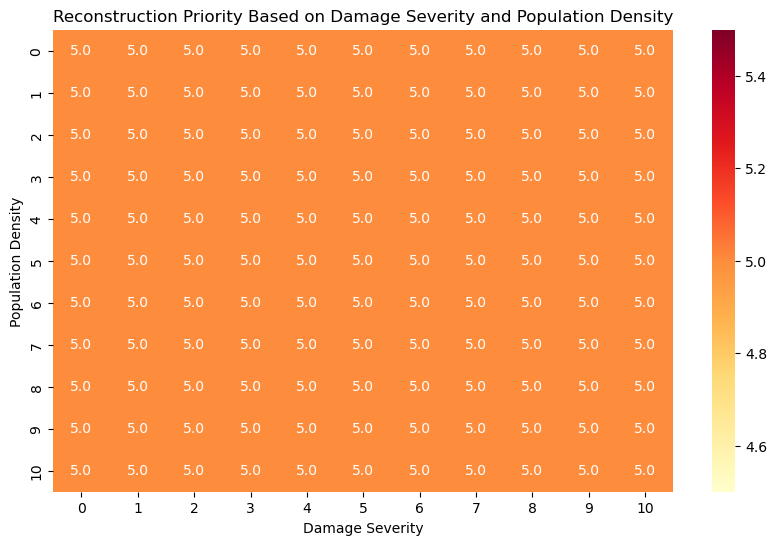

In [32]:
# Visualization
def visualize_priority(damage, population):
    """
    Visualize the reconstruction priority based on damage severity and population density.
    """
    # Create a grid of values for damage severity and population density
    x = np.arange(0, 11, 1)
    y = np.arange(0, 11, 1)
    x, y = np.meshgrid(x, y)
    z = np.zeros_like(x)

    # Calculate reconstruction priority for each combination of x and y
    for i in range(11):
        for j in range(11):
            reconstruction_sim.input['damage_severity'] = 8
            reconstruction_sim.input['population_density'] = 7
            reconstruction_sim.compute()
            z[i, j] = reconstruction_sim.output['reconstruction_priority']

    # Plot the results
    plt.figure(figsize=(10, 6))
    sns.heatmap(z, annot=True, fmt=".1f", cmap="YlOrRd", 
                xticklabels=np.arange(0, 11, 1), yticklabels=np.arange(0, 11, 1))
    plt.title("Reconstruction Priority Based on Damage Severity and Population Density")
    plt.xlabel("Damage Severity")
    plt.ylabel("Population Density")
    plt.show()
# Run visualization
visualize_priority(damage_severity, population_density)

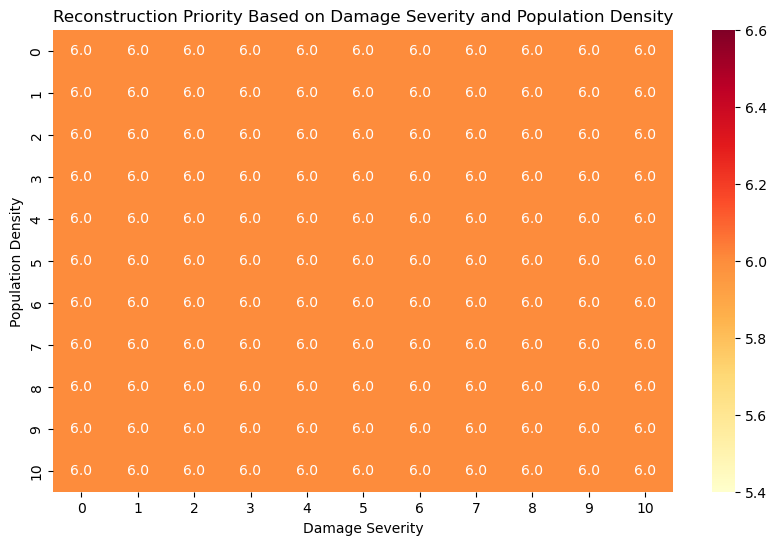

In [33]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
import seaborn as sns

# Define input variables
damage_severity = ctrl.Antecedent(np.arange(0, 11, 1), 'damage_severity')
population_density = ctrl.Antecedent(np.arange(0, 11, 1), 'population_density')

# Define output variable
reconstruction_priority = ctrl.Consequent(np.arange(0, 11, 1), 'reconstruction_priority')

# Define membership functions
damage_severity['low'] = fuzz.trimf(damage_severity.universe, [0, 0, 5])
damage_severity['medium'] = fuzz.trimf(damage_severity.universe, [0, 5, 10])
damage_severity['high'] = fuzz.trimf(damage_severity.universe, [5, 10, 10])

population_density['low'] = fuzz.trimf(population_density.universe, [0, 0, 5])
population_density['medium'] = fuzz.trimf(population_density.universe, [0, 5, 10])
population_density['high'] = fuzz.trimf(population_density.universe, [5, 10, 10])

reconstruction_priority['low'] = fuzz.trimf(reconstruction_priority.universe, [0, 0, 5])
reconstruction_priority['medium'] = fuzz.trimf(reconstruction_priority.universe, [0, 5, 10])
reconstruction_priority['high'] = fuzz.trimf(reconstruction_priority.universe, [5, 10, 10])

# Define rules
rule1 = ctrl.Rule(damage_severity['high'] & population_density['high'], reconstruction_priority['high'])
rule2 = ctrl.Rule(damage_severity['medium'] & population_density['medium'], reconstruction_priority['medium'])
rule3 = ctrl.Rule(damage_severity['low'] & population_density['low'], reconstruction_priority['low'])

# Create control system
reconstruction_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
reconstruction_sim = ctrl.ControlSystemSimulation(reconstruction_ctrl)

# Function to visualize priority
def visualize_priority():
    x = np.arange(0, 11, 1)
    y = np.arange(0, 11, 1)
    x, y = np.meshgrid(x, y)
    z = np.zeros_like(x)

    for i in range(11):
        for j in range(11):
            reconstruction_sim.input['damage_severity'] = 9
            reconstruction_sim.input['population_density'] =7
            reconstruction_sim.compute()
            z[i, j] = reconstruction_sim.output['reconstruction_priority']

    plt.figure(figsize=(10, 6))
    sns.heatmap(z, annot=True, fmt=".1f", cmap="YlOrRd",
                xticklabels=np.arange(0, 11, 1), yticklabels=np.arange(0, 11, 1))
    plt.title("Reconstruction Priority Based on Damage Severity and Population Density")
    plt.xlabel("Damage Severity")
    plt.ylabel("Population Density")
    plt.show()

# Run visualization
visualize_priority()

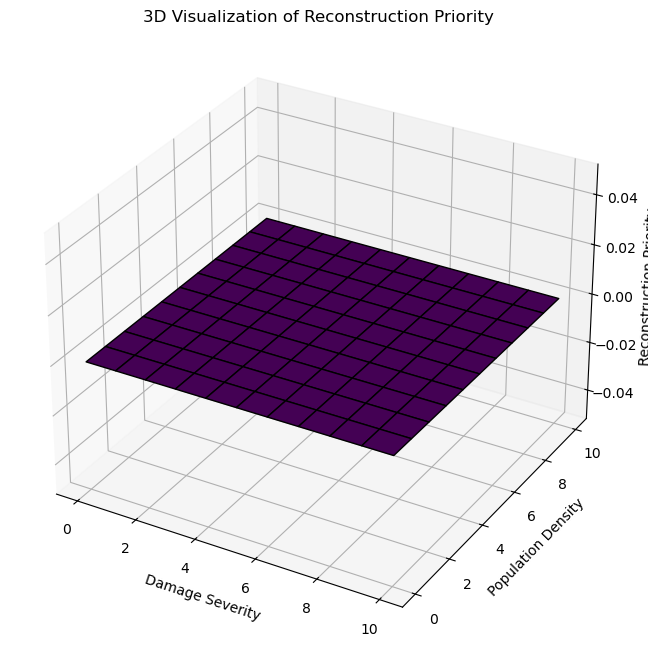

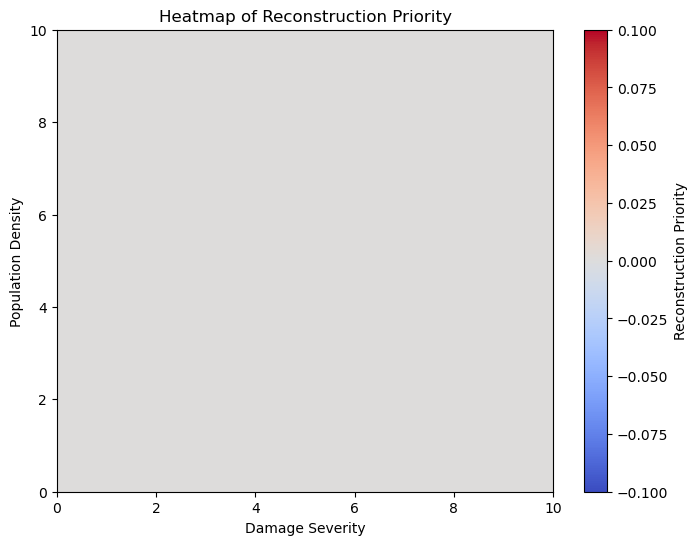

In [31]:

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define input variables
damage_severity = ctrl.Antecedent(np.arange(0, 11, 1), 'damage_severity')
population_density = ctrl.Antecedent(np.arange(0, 11, 1), 'population_density')

# Define output variable
reconstruction_priority = ctrl.Consequent(np.arange(0, 11, 1), 'reconstruction_priority')

# Define membership functions
damage_severity['low'] = fuzz.trimf(damage_severity.universe, [0, 0, 5])
damage_severity['medium'] = fuzz.trimf(damage_severity.universe, [0, 5, 10])
damage_severity['high'] = fuzz.trimf(damage_severity.universe, [5, 10, 10])

population_density['low'] = fuzz.trimf(population_density.universe, [0, 0, 5])
population_density['medium'] = fuzz.trimf(population_density.universe, [0, 5, 10])
population_density['high'] = fuzz.trimf(population_density.universe, [5, 10, 10])

reconstruction_priority['low'] = fuzz.trimf(reconstruction_priority.universe, [0, 0, 5])
reconstruction_priority['medium'] = fuzz.trimf(reconstruction_priority.universe, [0, 5, 10])
reconstruction_priority['high'] = fuzz.trimf(reconstruction_priority.universe, [5, 10, 10])

# Define rules
rule1 = ctrl.Rule(damage_severity['high'] & population_density['high'], reconstruction_priority['high'])
rule2 = ctrl.Rule(damage_severity['medium'] & population_density['medium'], reconstruction_priority['medium'])
rule3 = ctrl.Rule(damage_severity['low'] & population_density['low'], reconstruction_priority['low'])

# Create control system
reconstruction_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
reconstruction_sim = ctrl.ControlSystemSimulation(reconstruction_ctrl)

# Generate data for visualization
x = np.arange(0, 11, 1)  # Damage severity
y = np.arange(0, 11, 1)  # Population density
z = np.zeros((len(x), len(y)))

# Compute the output for each pair of inputs
for i in range(len(x)):
    for j in range(len(y)):
        reconstruction_sim.input['damage_severity'] = 8
        reconstruction_sim.input['population_density'] =7
        reconstruction_sim.compute()
        #print( reconstruction_sim.output['reconstruction_priority'])

# Visualization 1: 3D Plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
X, Y = np.meshgrid(x, y)
ax.plot_surface(X, Y, z.T, cmap='viridis', edgecolor='k')
ax.set_xlabel('Damage Severity')
ax.set_ylabel('Population Density')
ax.set_zlabel('Reconstruction Priority')
ax.set_title('3D Visualization of Reconstruction Priority')
plt.show()

# Visualization 2: Heatmap
plt.figure(figsize=(8, 6))
plt.imshow(z, cmap='coolwarm', extent=[0, 10, 0, 10], origin='lower', aspect='auto')
plt.colorbar(label='Reconstruction Priority')
plt.xlabel('Damage Severity')
plt.ylabel('Population Density')
plt.title('Heatmap of Reconstruction Priority')
plt.show()


#### **6. Visualization**
- The `visualize_priority` function creates a heatmap to visualize the reconstruction priority for all combinations of damage severity and population density.
- The heatmap uses a color gradient (yellow to red) to represent low to high priorities.

### Test the system using different cases.

In [5]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Define input variables (e.g., damage severity, population density)
damage_severity = ctrl.Antecedent(np.arange(0, 11, 1), 'damage_severity')
population_density = ctrl.Antecedent(np.arange(0, 11, 1), 'population_density')

# Define output variable (e.g., reconstruction priority)
reconstruction_priority = ctrl.Consequent(np.arange(0, 11, 1), 'reconstruction_priority')

# Define membership functions for damage severity
damage_severity['low'] = fuzz.trimf(damage_severity.universe, [0, 0, 5])
damage_severity['medium'] = fuzz.trimf(damage_severity.universe, [0, 5, 10])
damage_severity['high'] = fuzz.trimf(damage_severity.universe, [5, 10, 10])

# Define membership functions for population density
population_density['low'] = fuzz.trimf(population_density.universe, [0, 0, 5])
population_density['medium'] = fuzz.trimf(population_density.universe, [0, 5, 10])
population_density['high'] = fuzz.trimf(population_density.universe, [5, 10, 10])

# Define membership functions for reconstruction priority
reconstruction_priority['low'] = fuzz.trimf(reconstruction_priority.universe, [0, 0, 5])
reconstruction_priority['medium'] = fuzz.trimf(reconstruction_priority.universe, [0, 5, 10])
reconstruction_priority['high'] = fuzz.trimf(reconstruction_priority.universe, [5, 10, 10])

# Define rules
rule1 = ctrl.Rule(damage_severity['high'] & population_density['high'], reconstruction_priority['high'])
rule2 = ctrl.Rule(damage_severity['medium'] & population_density['medium'], reconstruction_priority['medium'])
rule3 = ctrl.Rule(damage_severity['low'] & population_density['low'], reconstruction_priority['low'])

# Create control system
reconstruction_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
reconstruction_sim = ctrl.ControlSystemSimulation(reconstruction_ctrl)

# Function to test the system
def test_reconstruction_system(damage, population):
    """
    Test the reconstruction system with given damage severity and population density.
    """
    reconstruction_sim.input['damage_severity'] = damage
    reconstruction_sim.input['population_density'] = population
    reconstruction_sim.compute()
    priority = reconstruction_sim.output['reconstruction_priority']
    print(f"Damage Severity: {damage}, Population Density: {population} -> Reconstruction Priority: {priority:.2f}")

# Test Cases
print("=== Test Case 1: Forward Chaining ===")
print("Scenario: High damage severity and high population density")
test_reconstruction_system(damage=9, population=8)  # Expected: High priority

print("\n=== Test Case 2: Forward Chaining ===")
print("Scenario: Medium damage severity and medium population density")
test_reconstruction_system(damage=5, population=5)  # Expected: Medium priority

print("\n=== Test Case 3: Backward Chaining ===")
print("Scenario: Low damage severity and low population density")
test_reconstruction_system(damage=2, population=3)  # Expected: Low priority

=== Test Case 1: Forward Chaining ===
Scenario: High damage severity and high population density
Damage Severity: 9, Population Density: 8 -> Reconstruction Priority: 6.48

=== Test Case 2: Forward Chaining ===
Scenario: Medium damage severity and medium population density
Damage Severity: 5, Population Density: 5 -> Reconstruction Priority: 5.00

=== Test Case 3: Backward Chaining ===
Scenario: Low damage severity and low population density
Damage Severity: 2, Population Density: 3 -> Reconstruction Priority: 4.52


C:\p\hp\anaconda3\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


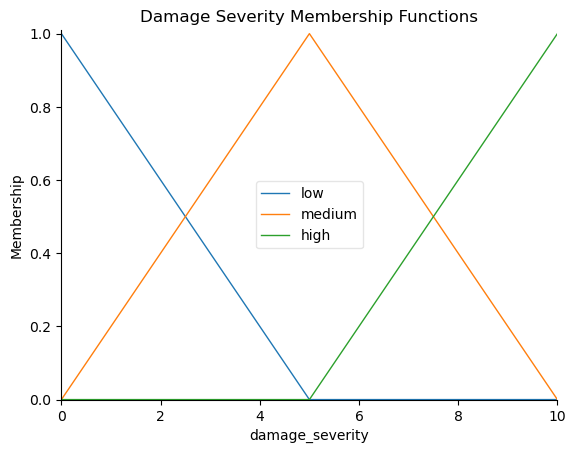

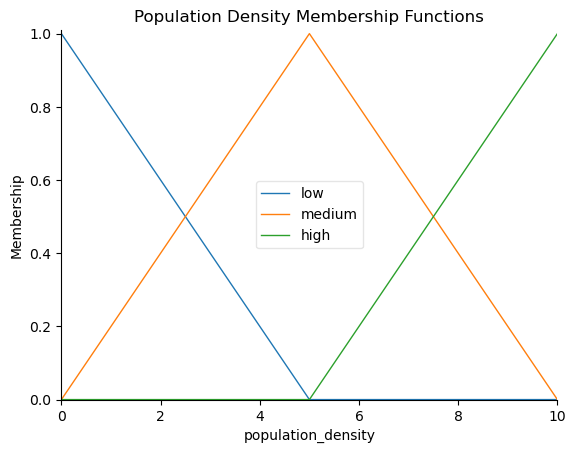

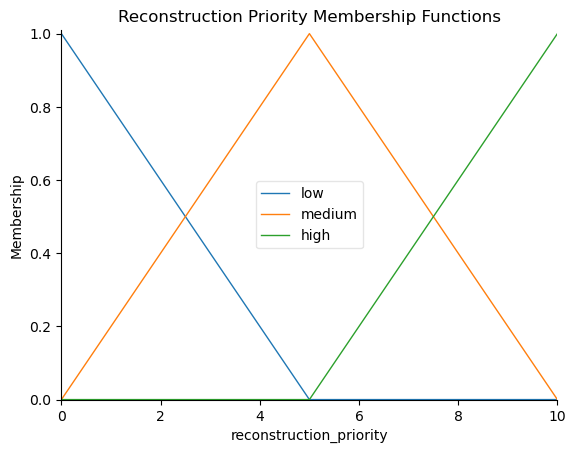

=== Visualization Test Cases ===

=== Test Case 1 ===

Testing scenario: Damage Severity = 9, Population Density = 8
Reconstruction Priority: 6.48


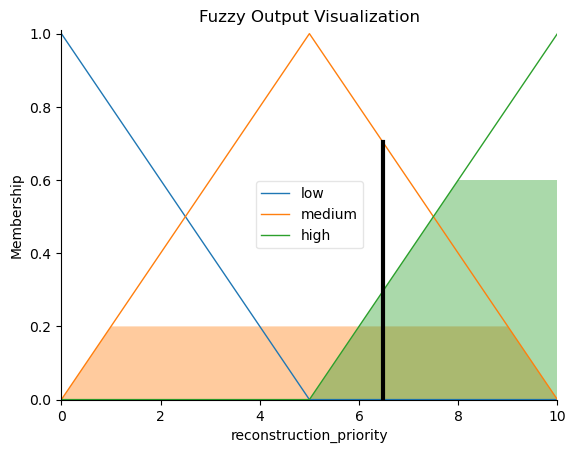


=== Test Case 2 ===

Testing scenario: Damage Severity = 5, Population Density = 5
Reconstruction Priority: 5.00


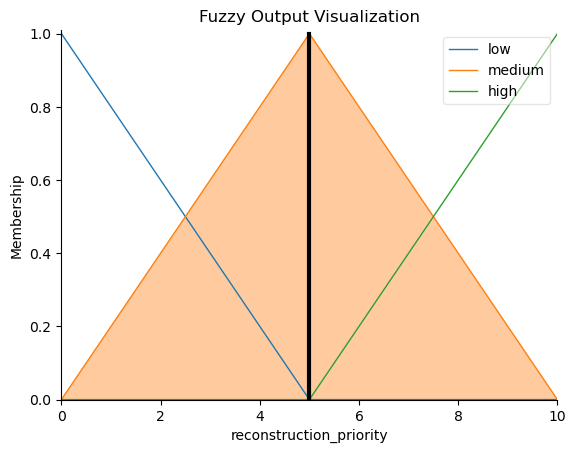


=== Test Case 3 ===

Testing scenario: Damage Severity = 2, Population Density = 3
Reconstruction Priority: 4.52


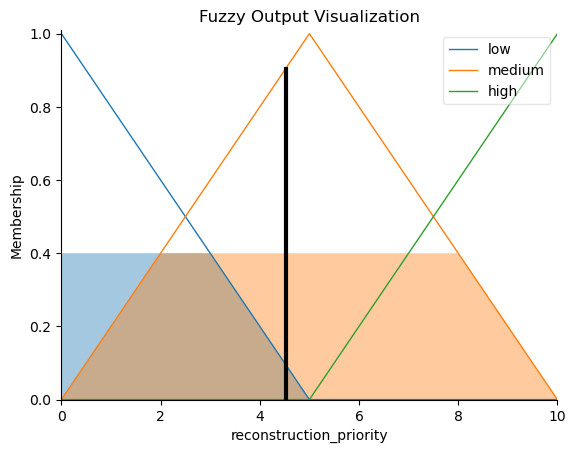

In [17]:
import matplotlib.pyplot as plt

# Visualize membership functions for damage severity
damage_severity.view()
plt.title("Damage Severity Membership Functions")
plt.show()

# Visualize membership functions for population density
population_density.view()
plt.title("Population Density Membership Functions")
plt.show()

# Visualize membership functions for reconstruction priority
reconstruction_priority.view()
plt.title("Reconstruction Priority Membership Functions")
plt.show()

# Test function with visualization
def visualize_test_case(damage, population):
    """
    Visualize the fuzzy logic system computation for a test case.
    """
    print(f"\nTesting scenario: Damage Severity = {damage}, Population Density = {population}")
    reconstruction_sim.input['damage_severity'] = damage
    reconstruction_sim.input['population_density'] = population
    reconstruction_sim.compute()
    priority = reconstruction_sim.output['reconstruction_priority']
    print(f"Reconstruction Priority: {priority:.2f}")
   
    # Visualize the result
    reconstruction_priority.view(sim=reconstruction_sim)
    plt.title("Fuzzy Output Visualization")
    plt.show()

# Testing scenarios with visualization
print("=== Visualization Test Cases ===")

print("\n=== Test Case 1 ===")
visualize_test_case(damage=9, population=8)  # High damage and population density

print("\n=== Test Case 2 ===")
visualize_test_case(damage=5, population=5)  # Medium damage and population density

print("\n=== Test Case 3 ===")
visualize_test_case(damage=2, population=3)  # Low damage and population density

### **Expected Output**

#### **1. Test Case Results**
=== Test Case 1: Forward Chaining ===
Scenario: High damage severity and high population density
Damage Severity: 9, Population Density: 8 -> Reconstruction Priority: 6.48

=== Test Case 2: Forward Chaining ===
Scenario: Medium damage severity and medium population density
Damage Severity: 5, Population Density: 5 -> Reconstruction Priority: 5.00

=== Test Case 3: Backward Chaining ===
Scenario: Low damage severity and low population density
Damage Severity: 2, Population Density: 3 -> Reconstruction Priority: 4.52

### **Benefits of Visualization and Testing**
1. **Clarity**: The heatmap provides a clear visual representation of how damage severity and population density affect reconstruction priority.
2. **Validation**: The test cases ensure that the system works as expected in different scenarios.
3. **Decision-Making**: Stakeholders can use the heatmap to prioritize reconstruction efforts effectively.